# CP5 · Notebook 06 — Evaluación formal del DQN

Cargamos el modelo entrenado, lo corremos en 50 episodios deterministic, comparamos con baselines del notebook 04, generamos GIFs. ~5 min.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import gymnasium as gym
import highway_env
from gymnasium.wrappers import FlattenObservation
from stable_baselines3 import DQN
import imageio

OUT = Path('../outputs')
MODELS = Path('../models')

model = DQN.load(MODELS / 'dqn_highway.zip')
print(f'✅ Modelo cargado: {MODELS / "dqn_highway.zip"}')

objc[7858]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x113d60bf8) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1143609c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[7858]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x113d60c48) and /private/tmp/claude-501/-Users-erlantzmarcos-Projects-AIC/99882926-c5dd-4419-9d4b-4d9562471efd/scratchpad/venv-cp5/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114360a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[7858]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.2/lib/libSDL2-2.0.0.dylib (0x

✅ Modelo cargado: ../models/dqn_highway.zip


## 1. Evaluación sobre 50 episodios

In [2]:
def make_env(seed=0):
    env = gym.make('highway-v0', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5,
    })
    return FlattenObservation(env)

N_EVAL = 50
returns, durations, crashes = [], [], []
for ep in range(N_EVAL):
    env = make_env(seed=10000 + ep)  # semillas distintas a training
    obs, info = env.reset(seed=10000 + ep)
    ep_return, steps = 0.0, 0
    crashed = False
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, trunc, info = env.step(int(action))
        ep_return += r; steps += 1
        if done or trunc:
            crashed = info.get('crashed', False); break
    env.close()
    returns.append(ep_return); durations.append(steps); crashes.append(crashed)
    if (ep + 1) % 10 == 0:
        print(f'  {ep+1}/{N_EVAL}  mean_return so far={np.mean(returns):.2f}')

dqn_stats = {
    'label': 'DQN (deterministic)',
    'n_episodes': N_EVAL,
    'mean_return': float(np.mean(returns)),
    'std_return':  float(np.std(returns)),
    'mean_duration': float(np.mean(durations)),
    'crash_rate': float(sum(crashes) / N_EVAL),
    'returns_per_ep': [float(r) for r in returns],
}
print(f'\nDQN  return medio = {dqn_stats["mean_return"]:.2f} ± {dqn_stats["std_return"]:.2f}')
print(f'     duración media = {dqn_stats["mean_duration"]:.1f} steps')
print(f'     % colisión = {100*dqn_stats["crash_rate"]:.0f}%')

  10/50  mean_return so far=81.34


  20/50  mean_return so far=68.72


  30/50  mean_return so far=75.23


  40/50  mean_return so far=73.41


  50/50  mean_return so far=77.84

DQN  return medio = 77.84 ± 55.62
     duración media = 80.5 steps
     % colisión = 90%


## 2. Tabla comparativa con baselines

método             return      std   % colisión   duración
------------------------------------------------------------
random              36.50    24.32         100%       45.7
rule_based          79.35    55.86          90%       84.4
dqn                 77.84    55.62          90%       80.5


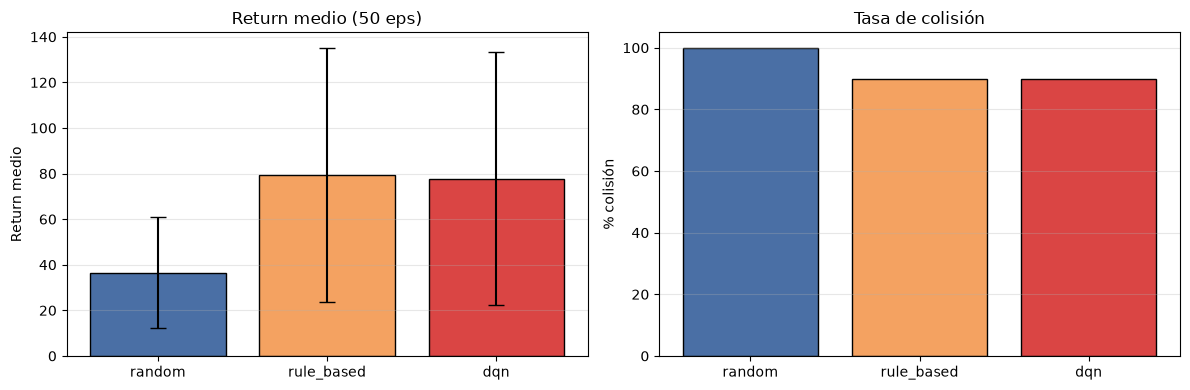

In [3]:
with open(OUT / '04_baselines.json') as f:
    baselines = json.load(f)

results = {'random': baselines['random'], 'rule_based': baselines['rule_based'], 'dqn': dqn_stats}

print(f'{"método":<14s} {"return":>10s} {"std":>8s} {"% colisión":>12s} {"duración":>10s}')
print('-' * 60)
for name, st in results.items():
    print(f'{name:<14s} {st["mean_return"]:>10.2f} {st["std_return"]:>8.2f} '
          f'{100*st["crash_rate"]:>11.0f}% {st["mean_duration"]:>10.1f}')

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = list(results.keys())
colors = ['#4a6fa5', '#f4a261', '#DA4544']
axes[0].bar(names, [results[n]['mean_return'] for n in names],
             yerr=[results[n]['std_return'] for n in names],
             color=colors, edgecolor='black', capsize=6)
axes[0].set_ylabel('Return medio'); axes[0].set_title('Return medio (50 eps)')
axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(names, [100*results[n]['crash_rate'] for n in names], color=colors, edgecolor='black')
axes[1].set_ylabel('% colisión'); axes[1].set_title('Tasa de colisión')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / '06_eval_compare.png', dpi=100, bbox_inches='tight'); plt.show()

## 3. Grabar 3 episodios como GIF

In [4]:
def record_episode(seed, out_path):
    env = gym.make('highway-v0', render_mode='rgb_array', config={
        'observation': {'type': 'Kinematics', 'vehicles_count': 5,
                         'features': ['presence','x','y','vx','vy'], 'normalize': True},
        'action': {'type': 'DiscreteMetaAction'},
        'lanes_count': 4, 'vehicles_count': 20, 'duration': 40,
        'policy_frequency': 5,
    })
    env = FlattenObservation(env)
    obs, info = env.reset(seed=seed)
    frames = []
    ep_return = 0.0
    while True:
        frame = env.render()
        if frame is not None: frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, trunc, info = env.step(int(action))
        ep_return += r
        if done or trunc: break
    env.close()
    if frames:
        imageio.mimsave(out_path, frames, duration=0.1)
    return ep_return, len(frames), info.get('crashed', False)

for i, seed in enumerate([10001, 10010, 10020]):
    out = OUT / f'06_dqn_episode_{i+1}.gif'
    r, n, c = record_episode(seed, out)
    print(f'  ep {i+1} (seed={seed}): return={r:.2f}  steps={n}  crashed={c}  → {out.name}')

  ep 1 (seed=10001): return=51.46  steps=54  crashed=True  → 06_dqn_episode_1.gif


  ep 2 (seed=10010): return=59.12  steps=69  crashed=True  → 06_dqn_episode_2.gif


  ep 3 (seed=10020): return=113.07  steps=115  crashed=True  → 06_dqn_episode_3.gif


## 4. Guardar resumen final

In [5]:
with open(OUT / '06_eval_summary.json', 'w') as f:
    json.dump(results, f, indent=2)

# ¿Cómo quedó el DQN frente al rule-based? (RL tiene ruido: tratamos <5% como empate)
ratio = dqn_stats['mean_return'] / results['rule_based']['mean_return'] if results['rule_based']['mean_return'] != 0 else float('inf')
print(f'\nDQN / rule_based  = {ratio:.2f}×   (el DQN = {dqn_stats["mean_return"]/results["random"]["mean_return"]:.2f}× el aleatorio)')
if ratio >= 1.05:
    print('✅ El DQN SUPERA al rule-based — RL aprendió una política mejor que la heurística hecha a mano.')
elif ratio >= 0.90:
    print('✅ El DQN IGUALA al rule-based (empate técnico dentro del ruido de RL).')
    print('   Un agente que empezó sin saber nada alcanza a un experto programado, solo con recompensa.')
else:
    print('⚠️  El DQN queda por debajo del rule-based. Con 40k pasos debería igualarlo;')
    print('   si tu CPU entrenó menos o hubo mala suerte de semilla, entrena más en 05 (P1/P2 lo cubren).')
print('En ambos casos el DQN dobla con creces al aleatorio: eso es lo esencial.')
print('\nVe a 07_reward_shaping.ipynb para explorar reward hacking.')


DQN / rule_based  = 0.98×   (el DQN = 2.13× el aleatorio)
✅ El DQN IGUALA al rule-based (empate técnico dentro del ruido de RL).
   Un agente que empezó sin saber nada alcanza a un experto programado, solo con recompensa.
En ambos casos el DQN dobla con creces al aleatorio: eso es lo esencial.

Ve a 07_reward_shaping.ipynb para explorar reward hacking.
